<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Data_mining_sl_Multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimation of house price given set of independent variable
Step 1 : import data
Step 2 : Data cleaning -
  a. Duplicate values
  b.missing values
  c.Outliers
Step 3 : Data pre-processing
  handle categorical columns- Label encoding / one hot encoding
step 4 : EXploratory Data analysis
  a. extract descriptive statistic- insights
  b. perform hypothesis testing - inference
  c. Correlation matrix - to check multicollinearity
Step 5 : Fit Machine learning algorithm
  a.scaling of the data - Standard scaler, min max scaler , robust scaler.
  b.train and test split.
  c.Fit the machine learning model
Step 6 - Model diagnostic
  a. Extract the predicted values
  b. test for model assumptions
  


In [ ]:
#module to deal with dataframe - pandas
import pandas as pd

In [ ]:
#import data house price data
df = pd.read_csv('/Housing_encoded_data.csv')

In [ ]:
from google.colab import drive


In [ ]:
#verify whether the data is succesfully imported
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,2
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,2
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,3
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,3


In [ ]:
#to verify last  5 rows of data
df.tail(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,3
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,2
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,3
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1
544,1750000,3850,3,1,2,1,0,0,0,0,0,0,3


In [ ]:
#data cleaning
#duplicate rows - if there are duplicates this will show true , if there are no duplicated it will show false
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
540,False
541,False
542,False
543,False


there are no duplicates in the data

In [ ]:
#checking the misisng values
df.isnull()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


NO missing values in this data

In [ ]:
#this function will give you how many missing values are there
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
#we need to check for outliers - we will import another library for visualizations
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: ylabel='price'>

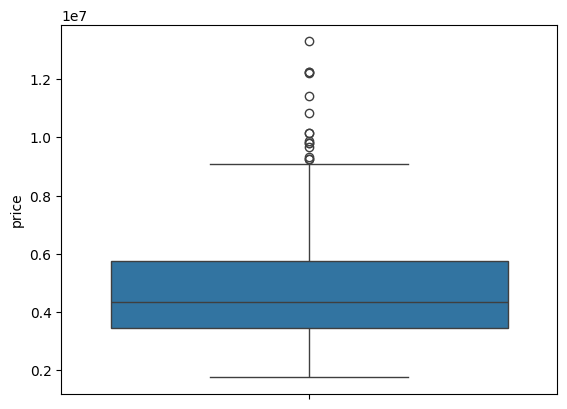

In [ ]:
sns.boxplot(df['price'])

<Axes: ylabel='area'>

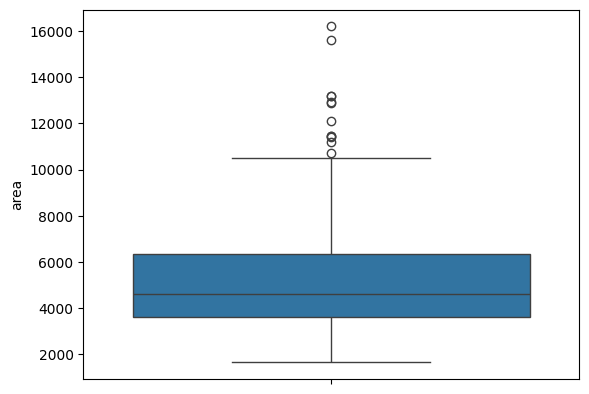

In [ ]:
sns.boxplot(df['area'])

<Axes: ylabel='bedrooms'>

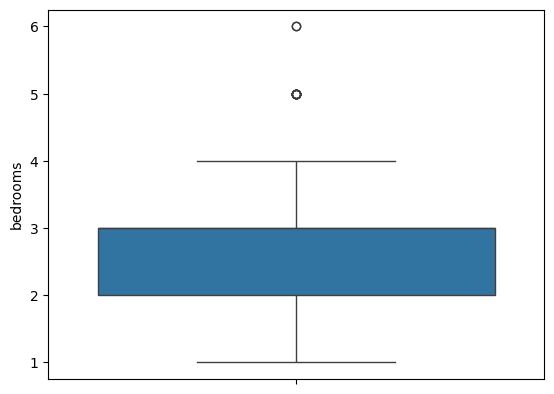

In [ ]:
sns.boxplot(df['bedrooms'])

<Axes: ylabel='bathrooms'>

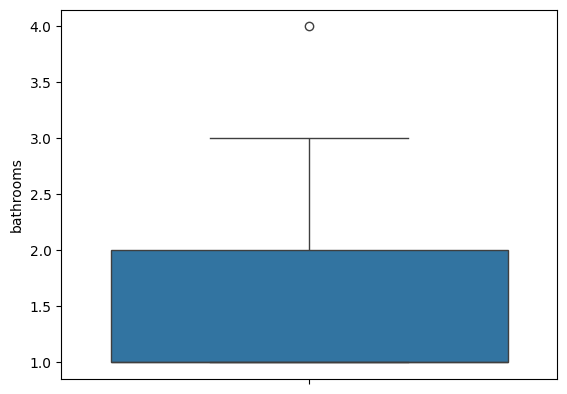

In [ ]:
sns.boxplot(df['bathrooms'])

<Axes: ylabel='stories'>

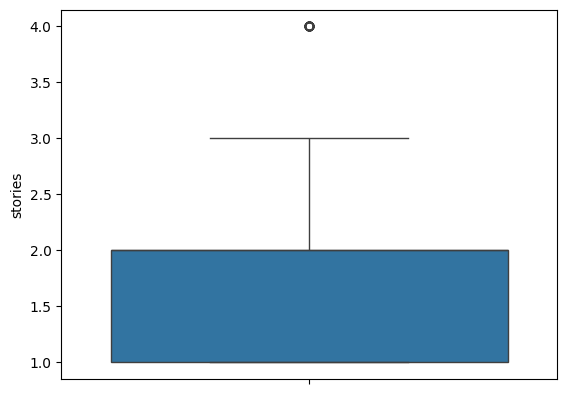

In [ ]:
sns.boxplot(df['stories'])

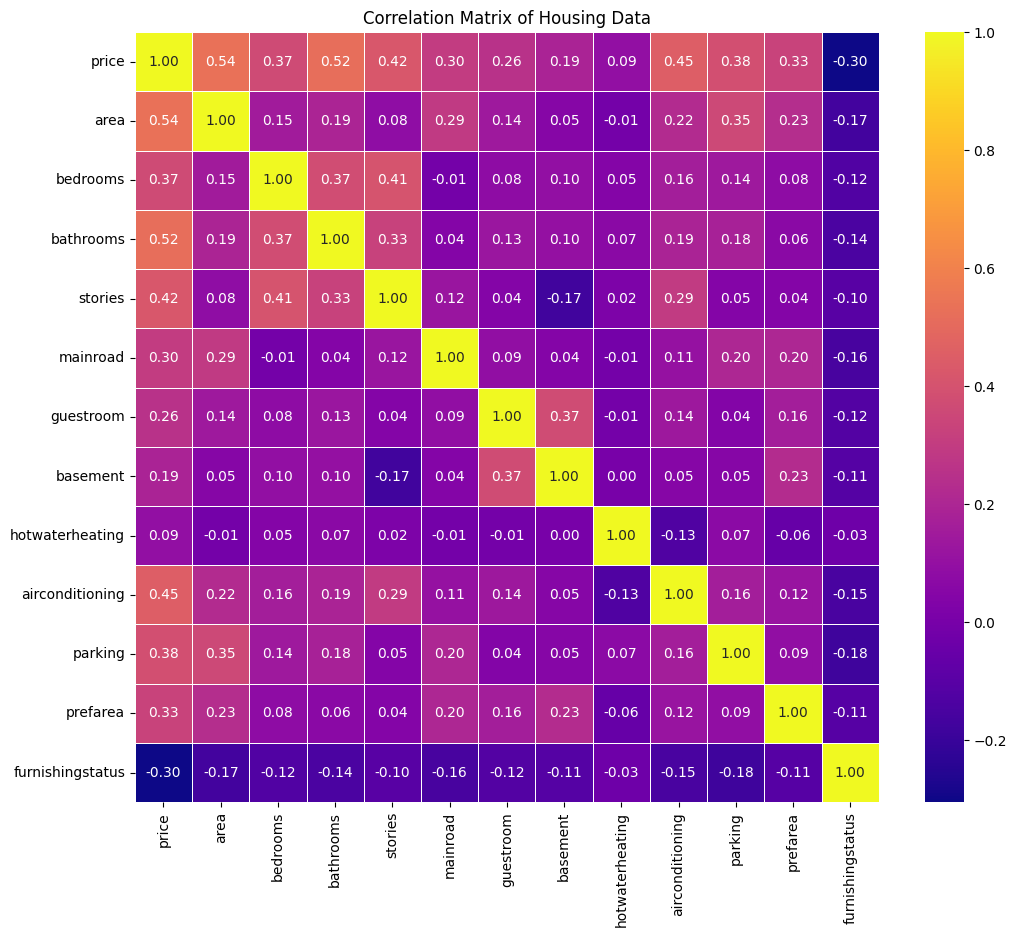

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Housing Data')
plt.show()
#if there are two variables then you can have scatter plot of correlation matrix
#if more than two heatmap is used
#what is multicollinerity and what is high multicollinearity , then how to identify
#multicollinearity

In [ ]:
from scipy.stats import f_oneway
import pandas as pd

# Ensure df is defined, assuming it's loaded from previous steps
# If df is not yet loaded, uncomment the following line and adjust the path if necessary:
# df = pd.read_csv('/Housing_encoded_data.csv')

# Get unique furnishing statuses
furnishing_statuses = df['furnishingstatus'].unique()

# Create a list of price arrays, one for each furnishing status group
price_groups = []
for status in furnishing_statuses:
    price_groups.append(df[df['furnishingstatus'] == status]['price'])

# Perform one-way ANOVA
f_statistic, p_value = f_oneway(*price_groups)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nSince the p-value is less than 0.05, we reject the null hypothesis.")
    print("This suggests that there is a statistically significant difference in mean house prices across different furnishing statuses.")
else:
    print("\nSince the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("This suggests that there is no statistically significant difference in mean house prices across different furnishing statuses.")

ANOVA F-statistic: 28.27
ANOVA p-value: 0.000

Since the p-value is less than 0.05, we reject the null hypothesis.
This suggests that there is a statistically significant difference in mean house prices across different furnishing statuses.


In [ ]:
# Get unique furnishing statuses to create groups for ANOVA
furnishing_statuses = df['furnishingstatus'].unique()

# Prepare price data for each furnishing status group
# Creating price groups based on furnishing status
price_groups = [df[df['furnishingstatus'] == status]['price'] for status in furnishing_statuses]

In [ ]:
# we are defining independennt and dependent variable
y = df['price']
x = df.drop(['price'],axis=1)
#why should you divide the data into train and test split

In [ ]:
#from where you will start teh split and why 80/20 why not 70/30

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,0,0,1,0,0,1,0,3
77,6500,3,2,3,1,0,0,0,1,0,1,1
360,4040,2,1,1,1,0,0,0,0,0,0,2
90,5000,3,1,2,1,0,0,0,1,0,0,2
493,3960,3,1,1,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,2
357,6930,4,1,2,0,0,0,0,0,1,0,1
39,6000,4,2,4,1,0,0,0,1,1,0,2
54,6000,3,2,2,1,1,0,0,1,1,0,2


In [ ]:
x_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1,0,0,0,1,1,0,1
93,7200,3,2,1,1,0,1,0,1,3,0,2
335,3816,2,1,1,1,0,1,0,1,2,0,1
412,2610,3,1,2,1,0,1,0,0,0,1,3
471,3750,3,1,2,1,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,3
106,5450,4,2,1,1,0,1,0,1,0,1,2
270,4500,3,2,3,1,0,0,1,0,1,0,1
435,4040,2,1,1,1,0,0,0,0,0,0,3


#Time series data is where data changes with time -

In [ ]:
import statsmodels.api as sm

# Add a constant to the independent variables (x_train) for the intercept term
x_train_sm = sm.add_constant(x_train)

# Create and fit the OLS (Ordinary Least Squares) model
lr_model = sm.OLS(y_train, x_train_sm).fit()

# Display the model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     76.81
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.36e-98
Time:                        07:43:18   Log-Likelihood:                -6635.6
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     423   BIC:                         1.335e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.035e+05   3.06e+05  

In [ ]:
# Drop the 'bedrooms' column from the independent variables
x_new = x.drop(['bedrooms'], axis=1)

# Re-split the data into training and testing sets with the updated x
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Add a constant to the new independent variables (x_train_new) for the intercept term
x_train_sm_new = sm.add_constant(x_train_new)

# Create and fit the new OLS (Ordinary Least Squares) model
lr_model_new = sm.OLS(y_train_new, x_train_sm_new).fit()

# Display the new model summary
print(lr_model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     83.68
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           6.13e-99
Time:                        07:53:08   Log-Likelihood:                -6636.1
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     424   BIC:                         1.335e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6.482e+05   2.73e+05  

The multiple linear regression model has been re-fitted after dropping the 'bedrooms' column. You can now compare this summary with the previous one to observe the changes in coefficients, R-squared, and p-values.

The multiple linear regression model has been fitted using `statsmodels`, and the summary provides details such as coefficients, p-values, R-squared, and other statistical metrics to evaluate the model's performance and the significance of each predictor.

In [ ]:
x_new2 = x.drop(['guestroom','bedrooms'], axis=1)

In [ ]:
x_new2

,area,bathrooms,stories,mainroad,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,2,3,1,0,0,1,2,1,1
1,8960,4,4,1,0,0,1,3,0,1
2,9960,2,2,1,1,0,0,2,1,2
3,7500,2,2,1,1,0,1,3,1,1
4,7420,1,2,1,1,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...
540,3000,1,1,1,1,0,0,2,0,3
541,2400,1,1,0,0,0,0,0,0,2
542,3620,1,1,1,0,0,0,0,0,3
543,2910,1,1,0,0,0,0,0,0,1


In [ ]:
# Re-split the data into training and testing sets with the updated x
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_new2, y, test_size=0.2, random_state=42)

# Add a constant to the new independent variables (x_train_2) for the intercept term
x_train_sm_new2 = sm.add_constant(x_train_2)

# Create and fit the new OLS (Ordinary Least Squares) model
lr_model_new2 = sm.OLS(y_train_2, x_train_sm_new2).fit()

# Display the new model summary
print(lr_model_new2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     91.42
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.32e-99
Time:                        08:01:13   Log-Likelihood:                -6637.5
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     425   BIC:                         1.334e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6.184e+05   2.73e+05  

from above output
1.all the independent variable are found to be significant since the p-value is less than 0.05

2.overall equation is also significant since the p value of f statistics is less than 0.05

3. intepretating r square r sqaure =0.689 which means that variation in estimating the price of house is explained by these sugnificant independent variable.


model diagnostics
inorder to conclude or use this ml equation on test data , the model has to fulfil model diagnostics of mlr

1.residuals are normally distributed

2.homoscedascity

3.no multicollinearity - extraxt variance inflation factor

we need to check for model diagonistics in that we have to check with standard residuals should be normally distributed , homoscatasticity , and no multi collinearity in independent variable


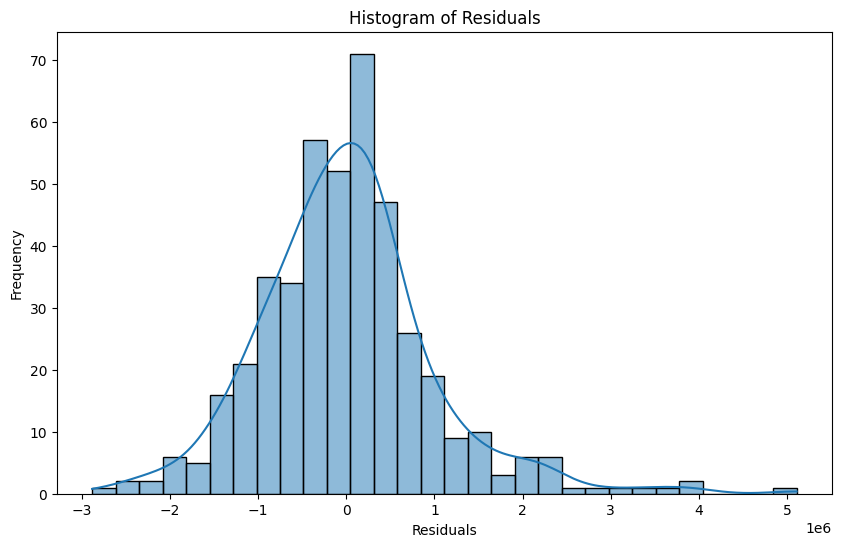

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals from the fitted model
residuals = lr_model_new2.resid

# Plot a histogram of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

This histogram helps visualize the distribution of your model's residuals. For a well-fitted model, the residuals should ideally be normally distributed around zero. You can assess whether the shape of this histogram resembles a normal distribution.

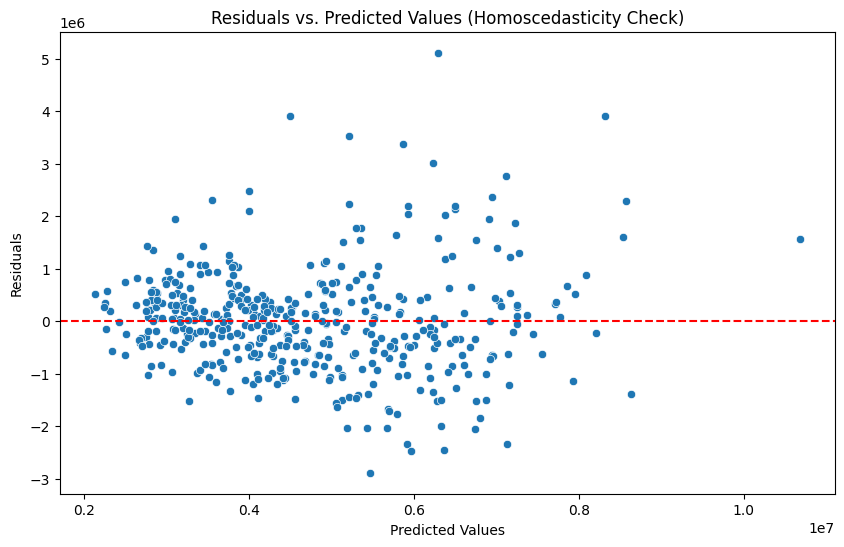

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the predicted values from the fitted model
predicted_values = lr_model_new2.predict(x_train_sm_new2)

# Get the residuals from the fitted model (already calculated)
# residuals = lr_model_new2.resid

# Create a scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

This scatter plot helps in evaluating the assumption of homoscedasticity (constant variance of residuals). Ideally, the points should be randomly scattered around the horizontal line at zero, with no clear pattern or fanning out. A funnel shape or other discernible pattern would indicate heteroscedasticity, meaning the variance of the errors is not constant.

In [ ]:
from statsmodels.stats.api import het_white

# Get the residuals from the fitted model
residuals = lr_model_new2.resid

# Get the independent variables (exog) used for the model
# Make sure to use the same x_train_sm_new2 that was used for fitting lr_model_new2
exog = x_train_sm_new2

# Perform White's test
lm, lm_pvalue, fvalue, f_pvalue = het_white(residuals, exog)

print(f"White's Test (Lagrange Multiplier Statistic): {lm:.3f}")
print(f"White's Test (LM p-value): {lm_pvalue:.3f}")
print(f"White's Test (F-Statistic): {fvalue:.3f}")
print(f"White's Test (F-p-value): {f_pvalue:.3f}")

if lm_pvalue < 0.05:
    print("\nSince the LM p-value is less than 0.05, we reject the null hypothesis.")
    print("This suggests the presence of heteroscedasticity.")
else:
    print("\nSince the LM p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("This suggests that heteroscedasticity is not detected.")

White's Test (Lagrange Multiplier Statistic): 146.390
White's Test (LM p-value): 0.000
White's Test (F-Statistic): 3.221
White's Test (F-p-value): 0.000

Since the LM p-value is less than 0.05, we reject the null hypothesis.
This suggests the presence of heteroscedasticity.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Assuming x_train_sm_new2 is the DataFrame with the independent variables and the constant term
# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data['feature'] = x_train_sm_new2.columns

# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(x_train_sm_new2.values, i) for i in range(x_train_sm_new2.shape[1])]

# Display the VIF values, sorted in descending order
print(vif_data.sort_values(by='VIF', ascending=False))

             feature        VIF
0              const  32.282534
3            stories   1.331679
1               area   1.276185
7    airconditioning   1.257746
2          bathrooms   1.212939
8            parking   1.203806
4           mainroad   1.170440
5           basement   1.162005
9           prefarea   1.136172
10  furnishingstatus   1.107611
6    hotwaterheating   1.037946


The Variance Inflation Factor (VIF) values have been calculated for each predictor.

*   A VIF value between 1 and 5 suggests a moderate correlation, which is generally acceptable.
*   A VIF value greater than 5 (or sometimes 10, depending on the context) indicates high multicollinearity, meaning that the predictor is highly correlated with other predictors in the model. This can make the model unstable and the interpretation of individual coefficients less reliable.

Review these values to identify if any variables are causing significant multicollinearity.

The White's test provides a more formal statistical assessment of homoscedasticity. A low p-value (typically less than 0.05) indicates that you should reject the null hypothesis of homoscedasticity, suggesting that heteroscedasticity is present in your model's residuals.